In [2]:
import pandas as pd

master_path = "master_transaction_pool.csv.gz"

# Read master pool
master_pool = pd.read_csv(master_path, compression="gzip")

# Labeled rows are those with a known fraud label (not -1)
labeled = master_pool[master_pool["is_fraud"] != -1]

banksim_labeled = (labeled["source_dataset"] == "banksim").sum()
non_banksim_labeled = (labeled["source_dataset"] != "banksim").sum()

print(f"Labeled transactions from banksim: {banksim_labeled:,}")
print(f"Labeled transactions not from banksim: {non_banksim_labeled:,}")
print(f"Total labeled transactions: {len(labeled):,}")

/tmp/ipykernel_406224/3448461925.py:6: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  master_pool = pd.read_csv(master_path, compression="gzip")


Labeled transactions from banksim: 594,643
Labeled transactions not from banksim: 58,710
Total labeled transactions: 653,353


In [3]:
# Read and print head of labels.csv.gz
labels = pd.read_csv("data/labels.csv.gz", compression="gzip")
print(labels.head())

counts = labels["label"].value_counts().reindex([1, 0], fill_value=0)

print(f"Fraud (1): {counts[1]}")
print(f"Not fraud (0): {counts[0]}")

       customer_id  label
0  SYNID0100000485      0
1  SYNID0100021236      0
2  SYNID0100036671      0
3  SYNID0100059315      0
4  SYNID0100060562      0
Fraud (1): 10
Not fraud (0): 990


In [4]:
kyc_individual = pd.read_csv("data/kyc_individual.csv.gz", compression="gzip")
print(f"Number of entries in kyc_individual.csv.gz: {len(kyc_individual):,}")

Number of entries in kyc_individual.csv.gz: 53,099


In [5]:
import pandas as pd

banksim_net = pd.read_csv("banksim/bsNET140513_032310.csv.gz", compression="gzip")
banksim_tx = pd.read_csv("banksim/bs140513_032310.csv.gz", compression="gzip")

print("bsNET140513_032310.csv.gz:")
print(banksim_net.head())

print("\nbs140513_032310.csv.gz:")
print(banksim_tx.head())

bsNET140513_032310.csv.gz:
          Source         Target  Weight            typeTrans  fraud
0  'C1093826151'   'M348934600'    4.55  'es_transportation'      0
1   'C352968107'   'M348934600'   39.68  'es_transportation'      0
2  'C2054744914'  'M1823072687'   26.89  'es_transportation'      0
3  'C1760612790'   'M348934600'   17.25  'es_transportation'      0
4   'C757503768'   'M348934600'   35.72  'es_transportation'      0

bs140513_032310.csv.gz:
   step       customer  age gender zipcodeOri       merchant zipMerchant  \
0     0  'C1093826151'  '4'    'M'    '28007'   'M348934600'     '28007'   
1     0   'C352968107'  '2'    'M'    '28007'   'M348934600'     '28007'   
2     0  'C2054744914'  '4'    'F'    '28007'  'M1823072687'     '28007'   
3     0  'C1760612790'  '3'    'M'    '28007'   'M348934600'     '28007'   
4     0   'C757503768'  '5'    'M'    '28007'   'M348934600'     '28007'   

              category  amount  fraud  
0  'es_transportation'    4.55      0  
1  

In [ ]:
# Total unique customers in banksim labeled data
total_banksim_customers = banksim_labeled["customer_id"].nunique()

# Customers with at least one fraud transaction
fraud_customers = banksim_labeled[banksim_labeled["is_fraud"] == 1]["customer_id"].nunique()

print(f"Total unique customers in banksim: {total_banksim_customers:,}")
print(f"Customers with at least one fraud transaction: {fraud_customers:,}")
print(f"Percentage: {fraud_customers / total_banksim_customers:.1%}")

NameError: name 'fraud_counts' is not defined

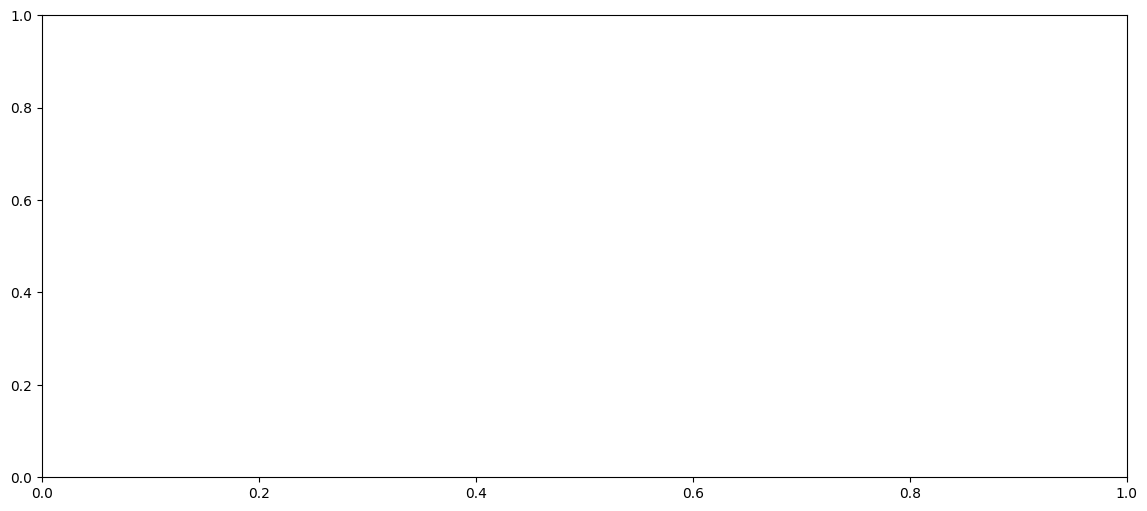

In [6]:
import matplotlib.pyplot as plt

# Bar chart: fraud transaction distribution per customer
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(fraud_counts.index, fraud_counts.values, color='steelblue', edgecolor='black')

ax.set_xlabel("Number of Fraud Transactions per Customer")
ax.set_ylabel("Number of Customers")
ax.set_title("Distribution of Fraud Transactions per Customer")

plt.tight_layout()
plt.show()


In [7]:
# Check fraud transaction patterns per customer in banksim dataset
banksim_labeled = labeled[labeled["source_dataset"] == "banksim"]

customer_fraud_status = banksim_labeled.groupby("customer_id")["is_fraud"].apply(lambda x: set(x)).reset_index()
customer_fraud_status.columns = ["customer_id", "fraud_values"]

# Categorize customers
always_fraud = customer_fraud_status[customer_fraud_status["fraud_values"] == {1.0}]
always_legit = customer_fraud_status[customer_fraud_status["fraud_values"] == {0.0}]
mixed = customer_fraud_status[~customer_fraud_status["fraud_values"].isin([{1.0}, {0.0}])]

print(f"Customers with ONLY fraudulent transactions: {len(always_fraud):,}")
print(f"Customers with ONLY legitimate transactions: {len(always_legit):,}")
print(f"Customers with MIXED transactions (both fraud and legit): {len(mixed):,}")

Customers with ONLY fraudulent transactions: 0
Customers with ONLY legitimate transactions: 2,629
Customers with MIXED transactions (both fraud and legit): 1,483


In [8]:
# Analyze fraud/legit time-sequence patterns for mixed customers
tx = banksim_labeled.copy()
tx["transaction_datetime"] = pd.to_datetime(tx["transaction_datetime"], errors="coerce")
tx = tx.sort_values(["customer_id", "transaction_datetime", "transaction_id"])

mixed_ids = set(mixed["customer_id"])
tx_mixed = tx[tx["customer_id"].isin(mixed_ids)]

def customer_time_pattern(g):
    seq = g["is_fraud"].astype(int).tolist()
    switches = sum(a != b for a, b in zip(seq, seq[1:]))
    first, last = seq[0], seq[-1]
    has_legit = 0 in seq
    has_fraud = 1 in seq

    if has_legit and has_fraud and switches == 1 and first == 0 and last == 1:
        pattern = "legit_then_fraud_once"
    elif has_legit and has_fraud and switches == 1 and first == 1 and last == 0:
        pattern = "fraud_then_legit_once"
    elif has_legit and has_fraud and switches > 1:
        pattern = "interleaved_multiple_switches"
    elif has_legit and not has_fraud:
        pattern = "always_legit"
    elif has_fraud and not has_legit:
        pattern = "always_fraud"
    else:
        pattern = "other"

    # Extra flags to directly test "once fraud starts, does legit appear again?"
    if has_fraud:
        first_fraud_idx = seq.index(1)
        legit_after_first_fraud = 0 in seq[first_fraud_idx + 1 :]
    else:
        legit_after_first_fraud = False

    if has_legit:
        first_legit_idx = seq.index(0)
        fraud_after_first_legit = 1 in seq[first_legit_idx + 1 :]
    else:
        fraud_after_first_legit = False

    return pd.Series({
        "n_tx": len(seq),
        "first_label": first,
        "last_label": last,
        "switches": switches,
        "pattern": pattern,
        "legit_after_first_fraud": legit_after_first_fraud,
        "fraud_after_first_legit": fraud_after_first_legit,
    })

pattern_df = tx_mixed.groupby("customer_id", sort=False).apply(customer_time_pattern).reset_index()

pattern_counts = pattern_df["pattern"].value_counts()
n = len(pattern_df)

print(f"Mixed customers analyzed: {n:,}\n")
for k in ["legit_then_fraud_once", "fraud_then_legit_once", "interleaved_multiple_switches"]:
    v = int(pattern_counts.get(k, 0))
    print(f"{k}: {v:,} ({v / n:.1%})")

print("\nSwitch-count summary (mixed customers):")
print(pattern_df["switches"].describe())

v = int(pattern_counts.get("legit_then_fraud_once", 0))
print(f"\nCustomers where fraud appears and then NO legit after first fraud: {v:,} ({v / n:.1%})")

i = int(pattern_counts.get("interleaved_multiple_switches", 0))
print(f"Customers with repeated back-and-forth (more random/interleaved): {i:,} ({i / n:.1%})")

Mixed customers analyzed: 1,483

legit_then_fraud_once: 26 (1.8%)
fraud_then_legit_once: 11 (0.7%)
interleaved_multiple_switches: 1,446 (97.5%)

Switch-count summary (mixed customers):
count    1483.000000
mean        6.045853
std         7.165900
min         1.000000
25%         2.000000
50%         4.000000
75%         8.000000
max       117.000000
Name: switches, dtype: float64

Customers where fraud appears and then NO legit after first fraud: 26 (1.8%)
Customers with repeated back-and-forth (more random/interleaved): 1,446 (97.5%)


/tmp/ipykernel_406224/440927408.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pattern_df = tx_mixed.groupby("customer_id", sort=False).apply(customer_time_pattern).reset_index()


In [9]:
model_output = pd.read_csv("model_output.csv")
print(model_output.head())

# Count fraud and legit predictions
value_counts = model_output.value_counts()
print("\nValue counts:")
print(value_counts)

       customer_id  predicted_label  risk_score
0  SYNID0100000167                0    0.001586
1  SYNID0100000431                0    0.028221
2  SYNID0100000485                0    0.000446
3  SYNID0100000539                0    0.000068
4  SYNID0100000932                0    0.000741

Value counts:
customer_id      predicted_label  risk_score
SYNID0100000167  0                0.001586      1
SYNID0107675525  0                0.006110      1
SYNID0107673413  0                0.110011      1
SYNID0107673980  0                0.000237      1
SYNID0107674033  0                0.005965      1
                                               ..
SYNID0103862582  0                0.000849      1
SYNID0103863017  0                0.009820      1
SYNID0103863069  0                0.002572      1
SYNID0103863126  0                0.000530      1
SYNID0200999998  0                0.008085      1
Name: count, Length: 61410, dtype: int64


In [11]:
predicted_fraud = (model_output["predicted_label"] == 1).sum()
print(f"Number of customers with predicted label 1: {predicted_fraud:,}")


Number of customers with predicted label 1: 36


In [ ]:
# Read probabilities
txn_probs = pd.read_csv(
    "txn_cnn_transaction_probs.csv.gz",
    compression="gzip",
    usecols=["txn_cnn_fraud_prob"]
)

# Basic distribution summary
p = txn_probs["txn_cnn_fraud_prob"].dropna()
print("Distribution summary for txn_cnn_fraud_prob:")
print(p.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# Bucketed distribution
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
bucket_counts = pd.cut(p, bins=bins, include_lowest=True).value_counts().sort_index()
print("\nBucket counts (0.1 width):")
print(bucket_counts)

# Histogram
ax = p.plot(kind="hist", bins=50, figsize=(10, 4), edgecolor="black")
ax.set_title("Distribution of txn_cnn_fraud_prob")
ax.set_xlabel("txn_cnn_fraud_prob")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

master_pool = pd.read_csv(
    "master_transaction_pool.csv.gz",
    compression="gzip",
)
print("Columns in master_transaction_pool.csv.gz:")
print(master_pool.columns.tolist())

Columns in master_transaction_pool.csv.gz:
['transaction_datetime', 'transaction_id', 'customer_id', 'amount_cad', 'debit_credit', 'merchant_category', 'ecommerce_ind', 'country', 'province', 'city', 'source_dataset', 'cash_indicator', 'prior_txn_count', 'is_cold_start', 'time_delta', 'velocity_24h', 'new_category_for_customer', 'amount_behavior_z', 'amount_30d_ratio', 'category_amount_z', 'cust_idx', 'cat_idx', 'city_idx']


In [ ]:
# Find a sample customer with 10-20 transactions
customer_counts = master_pool["customer_id"].value_counts()
eligible_customers = customer_counts[(customer_counts >= 10) & (customer_counts <= 20)]

if eligible_customers.empty:
    print("No customer found with 10-20 transactions.")
else:
    sample_customer_id = eligible_customers.index[0]
    sample_count = int(eligible_customers.iloc[0])

    customer_transactions = master_pool[master_pool["customer_id"] == sample_customer_id].copy()

    sort_cols = [c for c in ["transaction_datetime", "transaction_id"] if c in customer_transactions.columns]
    if "transaction_datetime" in customer_transactions.columns:
        customer_transactions["transaction_datetime"] = pd.to_datetime(
            customer_transactions["transaction_datetime"], errors="coerce"
        )
    if sort_cols:
        customer_transactions = customer_transactions.sort_values(sort_cols)

    print(f"Sample customer_id: {sample_customer_id}")
    print(f"Number of transactions: {sample_count}")
    display(customer_transactions)

In [2]:
import pandas as pd
# Re-read master pool from required path
master_pool = pd.read_csv("outputs/master_transaction_pool.csv.gz", compression="gzip")

# Find customers with 10-20 transactions
customer_counts = master_pool["customer_id"].value_counts()
eligible_customers = customer_counts[(customer_counts >= 10) & (customer_counts <= 20)]

if eligible_customers.empty:
    print("No customer found with 10-20 transactions.")
else:
    sample_customer_id = eligible_customers.index[0]
    sample_count = int(eligible_customers.iloc[0])

    customer_transactions = master_pool[master_pool["customer_id"] == sample_customer_id].copy()

    sort_cols = [c for c in ["transaction_datetime", "transaction_id"] if c in customer_transactions.columns]
    if "transaction_datetime" in customer_transactions.columns:
        customer_transactions["transaction_datetime"] = pd.to_datetime(
            customer_transactions["transaction_datetime"], errors="coerce"
        )
    if sort_cols:
        customer_transactions = customer_transactions.sort_values(sort_cols)

    print(f"Sample customer_id: {sample_customer_id}")
    print(f"Number of transactions: {sample_count}")
    display(customer_transactions)

Sample customer_id: SYNID0105472341
Number of transactions: 20


,transaction_datetime,transaction_id,customer_id,amount_cad,debit_credit,merchant_category,ecommerce_ind,country,province,city,...,new_category_for_customer,amount_behavior_z,amount_30d_ratio,category_amount_z,unique_categories_last10,distance_from_last_txn,geo_velocity_kmph,cust_idx,cat_idx,city_idx
2925599,2024-11-04 09:41:24,EFT24110492033723,SYNID0105472341,87.27,D,EFT,0,Canada,NaN,NaN,...,1,-0.032767,0.137059,-0.070733,0.0,0.0,0.000000,29171,0,0
2925600,2024-11-04 21:13:51,dxH4IdbJ,SYNID0105472341,27.76,D,EMT,0,Canada,NaN,NaN,...,1,-0.036316,0.043598,-0.466027,1.0,0.0,0.000000,29171,3,0
2925601,2024-11-09 23:07:30,CARD24110916873889,SYNID0105472341,0.00,D,4816,0,CA,ON,other,...,1,-0.037972,0.000000,-0.051694,2.0,3000.0,24.611515,29171,34,2
2925602,2024-11-17 19:07:20,yKargiYl,SYNID0105472341,1044.85,D,EMT,0,Canada,NaN,NaN,...,0,0.024338,1.640956,0.729279,3.0,3000.0,15.957683,29171,3,0
2925603,2024-11-23 13:45:56,CARD24112351732736,SYNID0105472341,1674.79,C,0,0,CA,SK,SASKATOON,...,1,0.061905,2.630288,0.320664,3.0,3000.0,21.638258,29171,30,26
2925604,2024-11-28 20:53:58,LFayZJKX,SYNID0105472341,31.23,C,EMT,0,Canada,NaN,NaN,...,0,-0.790205,0.055086,-0.993177,4.0,3000.0,23.597170,29171,3,0
2925605,2024-12-10 11:44:20,CARD24121013954439,SYNID0105472341,3.39,D,5814,0,CA,PE,other,...,1,-0.729329,0.003697,-0.408053,4.0,3000.0,10.758880,29171,6,2
2925606,2024-12-13 09:41:29,EFT24121364747729,SYNID0105472341,87.32,D,EFT,0,Canada,NaN,NaN,...,0,-0.516550,0.126814,0.000002,5.0,3000.0,42.886246,29171,0,0
2925607,2024-12-19 11:29:54,CARD24121931716280,SYNID0105472341,49.70,D,5200,0,NaN,NaN,other,...,1,-0.538679,0.110645,-0.071991,5.0,3000.0,20.575151,29171,71,2
2925608,2024-12-28 02:50:45,EFT24122886995917,SYNID0105472341,21.50,D,EFT,0,Canada,NaN,NaN,...,0,-0.549454,0.501049,-10.000000,6.0,3000.0,14.468465,29171,0,0


In [3]:
from pathlib import Path

data_dir = Path("data")
target_customer_id = sample_customer_id
target_txn_ids = set(customer_transactions["transaction_id"].astype(str))

print(f"Target customer_id: {target_customer_id}")
print(f"Target transactions in sample: {len(target_txn_ids)}")

# 1) Show raw file previews from /data
data_files = sorted(data_dir.glob("*.csv*"))
if not data_files:
    print("No CSV files found under /data.")
else:
    print("\n=== Raw /data file previews (first 3 rows each) ===")
    for fp in data_files:
        try:
            preview = pd.read_csv(fp, compression="infer", nrows=3)
            print(f"\n[{fp.name}] shape preview: {preview.shape}")
            display(preview)
        except Exception as e:
            print(f"\n[{fp.name}] could not be read: {e}")

# 2) Pull actual matching raw rows for this customer from /data files
print("\n=== Matching raw rows from /data for this customer ===")
for fp in data_files:
    try:
        # Read header only first
        cols = pd.read_csv(fp, compression="infer", nrows=0).columns.tolist()
        has_customer = "customer_id" in cols
        has_txn_id = "transaction_id" in cols

        if not (has_customer or has_txn_id):
            continue

        matched_parts = []
        for chunk in pd.read_csv(fp, compression="infer", chunksize=200_000):
            mask = pd.Series(False, index=chunk.index)

            if has_customer:
                mask |= chunk["customer_id"].astype(str).eq(target_customer_id)
            if has_txn_id:
                mask |= chunk["transaction_id"].astype(str).isin(target_txn_ids)

            part = chunk[mask]
            if not part.empty:
                matched_parts.append(part)

        if matched_parts:
            matched = pd.concat(matched_parts, ignore_index=True)
            print(f"\n[{fp.name}] matched rows: {len(matched):,}")
            display(matched)
    except Exception as e:
        print(f"\n[{fp.name}] error while matching: {e}")

# 3) Print KYC info for this customer from kyc files
print("\n=== KYC customer information ===")
kyc_files = sorted([f for f in data_files if "kyc" in f.name.lower()])

if not kyc_files:
    print("No KYC files found under /data.")
else:
    found_any_kyc = False
    for fp in kyc_files:
        try:
            cols = pd.read_csv(fp, compression="infer", nrows=0).columns.tolist()
            if "customer_id" not in cols:
                print(f"\n[{fp.name}] no customer_id column; showing preview:")
                display(pd.read_csv(fp, compression="infer", nrows=5))
                continue

            kyc_match = pd.read_csv(fp, compression="infer")
            kyc_match = kyc_match[kyc_match["customer_id"].astype(str).eq(target_customer_id)]

            print(f"\n[{fp.name}] matches: {len(kyc_match):,}")
            if not kyc_match.empty:
                found_any_kyc = True
                display(kyc_match)
        except Exception as e:
            print(f"\n[{fp.name}] could not be processed: {e}")

    if not found_any_kyc:
        print("No KYC records found for this customer_id.")

Target customer_id: SYNID0105472341
Target transactions in sample: 20

=== Raw /data file previews (first 3 rows each) ===

[abm.csv.gz] shape preview: (3, 9)


,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime,cash_indicator,country,province,city
0,ABM2411016110810,SYNID0104291988,300.0,D,2024-11-01 00:01:56,1,CA,BC,other
1,ABM2411013831558,SYNID0103664053,400.0,C,2024-11-01 00:03:09,1,CA,NS,other
2,ABM2411013725020,SYNID0106747172,400.0,D,2024-11-01 00:03:12,1,CA,BC,SURREY



[card.csv.gz] shape preview: (3, 10)


,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime,merchant_category,ecommerce_ind,country,province,city
0,CARD24110131109543,SYNID0102450742,13.35,D,2024-11-01 00:00:06,5812,1,CA,ON,NaN
1,CARD24110136178868,SYNID0105586872,6.05,D,2024-11-01 00:00:17,5968,1,NaN,NaN,other
2,CARD24110173783589,SYNID0107901560,81.40,C,2024-11-01 00:00:37,4816,0,CA,BC,NaN



[cheque.csv.gz] shape preview: (3, 5)


...


[kyc_industry_codes.csv.gz] no customer_id column; showing preview:


,industry_code,industry
0,112,Cattle Farms
1,119,Livestock Combination Farms
2,139,Other Field Crop Farms
3,141,Field Crop Combination Farms
4,171,"Livestock, Field Crop and Horticultural Combin..."



[kyc_occupation_codes.csv.gz] no customer_id column; showing preview:


,occupation_code,occupation_title
0,0,Legislative and senior management occupations
1,10010,Financial managers
2,10011,Human resources managers
3,10019,Other administrative services managers
4,10029,Other business services managers



[kyc_smallbusiness.csv.gz] matches: 0


In [ ]:
# Print the customer we found (10-20 transactions)
print(f"Customer found: {sample_customer_id}")
print(f"Transaction count in master pool: {sample_count}")

# 1) Customer information (from KYC files)
customer_info_parts = []
for fp in kyc_files:
    try:
        cols = pd.read_csv(fp, compression="infer", nrows=0).columns.tolist()
        if "customer_id" not in cols:
            continue

        kyc_df = pd.read_csv(fp, compression="infer")
        hit = kyc_df[kyc_df["customer_id"].astype(str).eq(sample_customer_id)].copy()
        if not hit.empty:
            hit.insert(0, "source_file", fp.name)
            customer_info_parts.append(hit)
    except Exception as e:
        print(f"Skipping {fp.name} (KYC read error): {e}")

if customer_info_parts:
    customer_info = pd.concat(customer_info_parts, ignore_index=True).drop_duplicates()
    print("\nCustomer information:")
    display(customer_info)
else:
    print("\nNo customer information found in KYC files.")

# 2) Raw transactions from actual transaction files
# IMPORTANT: keep each file's schema exactly as in the origin file
transaction_files = [
    f for f in data_files
    if "kyc" not in f.name.lower() and "labels" not in f.name.lower()
]

raw_by_file = {}    # {file_name: dataframe with original schema}
schema_by_file = {} # {file_name: original columns}

for fp in transaction_files:
    try:
        origin_cols = pd.read_csv(fp, compression="infer", nrows=0).columns.tolist()
        schema_by_file[fp.name] = origin_cols

        if "customer_id" not in origin_cols:
            continue

        matched_parts = []
        for chunk in pd.read_csv(fp, compression="infer", chunksize=200_000):
            part = chunk[chunk["customer_id"].astype(str).eq(sample_customer_id)].copy()
            if not part.empty:
                # enforce exact schema/order from source file
                part = part.reindex(columns=origin_cols)
                matched_parts.append(part)

        if matched_parts:
            tx_file_df = pd.concat(matched_parts, ignore_index=True).reindex(columns=origin_cols)
            raw_by_file[fp.name] = tx_file_df

    except Exception as e:
        print(f"Skipping {fp.name} (transaction read error): {e}")

if not raw_by_file:
    print("\nNo raw transactions found for this customer in transaction files.")
else:
    total_rows = sum(len(df) for df in raw_by_file.values())
    # print(f"\nRaw transaction matches found: {total_rows} rows across {len(raw_by_file)} file(s).")

    for fname, df_file in raw_by_file.items():
        origin_cols = schema_by_file[fname]
        schema_ok = (df_file.columns.tolist() == origin_cols)

        print(f"\n=== {fname} | rows: {len(df_file):,} | schema_match: {schema_ok} ===")
        if not schema_ok:
            print("WARNING: Extracted columns differ from source schema.")
            print("Source schema:", origin_cols)
            print("Extracted schema:", df_file.columns.tolist())

        # Human-readable view for display only (does not overwrite raw schema table)
        view = df_file.copy()

        if "transaction_datetime" in view.columns:
            view["transaction_datetime"] = pd.to_datetime(view["transaction_datetime"], errors="coerce")
            sort_cols = [c for c in ["transaction_datetime", "transaction_id"] if c in view.columns]
            if sort_cols:
                view = view.sort_values(sort_cols, na_position="last")
            view["transaction_datetime"] = view["transaction_datetime"].dt.strftime("%Y-%m-%d %H:%M:%S")

        if "debit_credit" in view.columns:
            view["debit_credit"] = view["debit_credit"].map({"D": "Debit", "C": "Credit"}).fillna(view["debit_credit"])

        if "amount_cad" in view.columns:
            view["amount_cad"] = view["amount_cad"].map(lambda x: f"${x:,.2f}" if pd.notna(x) else "—")

        display(view.fillna("—").reset_index(drop=True))

Customer found: SYNID0105472341
Transaction count in master pool: 20

Customer information:


,source_file,customer_id,country,province,city,gender,marital_status,occupation_code,income,birth_date,onboard_date
0,kyc_individual.csv.gz,SYNID0105472341,CA,NaN,other,MALE,Married,OTHER,55336.0,1951-05-10,1993-04-23



Raw transaction matches found: 20 rows across 3 file(s).

=== card.csv.gz | rows: 6 | schema_match: True ===


,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime,merchant_category,ecommerce_ind,country,province,city
0,CARD24110916873889,SYNID0105472341,$0.00,Debit,2024-11-09 23:07:30,4816,0,CA,ON,other
1,CARD24112351732736,SYNID0105472341,"$1,674.79",Credit,2024-11-23 13:45:56,0,0,CA,SK,SASKATOON
2,CARD24121013954439,SYNID0105472341,$3.39,Debit,2024-12-10 11:44:20,5814,0,CA,PE,other
3,CARD24121931716280,SYNID0105472341,$49.70,Debit,2024-12-19 11:29:54,5200,0,—,—,other
4,CARD24122920251500,SYNID0105472341,$47.31,Debit,2024-12-29 13:35:48,5921,0,CA,ON,TORONTO
5,CARD25011284945237,SYNID0105472341,$1.57,Debit,2025-01-12 13:22:40,7538,0,CA,ON,SCARBOROUGH



=== eft.csv.gz | rows: 7 | schema_match: True ===


,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime
0,EFT24110492033723,SYNID0105472341,$87.27,Debit,2024-11-04 09:41:24
1,EFT24121364747729,SYNID0105472341,$87.32,Debit,2024-12-13 09:41:29
2,EFT24122886995917,SYNID0105472341,$21.50,Debit,2024-12-28 02:50:45
3,EFT25011933546012,SYNID0105472341,"$1,194.45",Credit,2025-01-19 08:17:55
4,EFT25012657340440,SYNID0105472341,"$1,011.62",Credit,2025-01-26 08:18:10
5,EFT25012675781920,SYNID0105472341,"$1,310.94",Credit,2025-01-26 08:18:10
6,EFT25012637245926,SYNID0105472341,$780.49,Credit,2025-01-26 12:04:46



=== emt.csv.gz | rows: 7 | schema_match: True ===


,transaction_id,customer_id,amount_cad,debit_credit,transaction_datetime
0,dxH4IdbJ,SYNID0105472341,$27.76,Debit,2024-11-04 21:13:51
1,yKargiYl,SYNID0105472341,"$1,044.85",Debit,2024-11-17 19:07:20
2,LFayZJKX,SYNID0105472341,$31.23,Credit,2024-11-28 20:53:58
3,3oWlX95A,SYNID0105472341,$154.72,Credit,2025-01-05 22:08:46
4,906m4Zjn,SYNID0105472341,$32.50,Debit,2025-01-10 13:59:06
5,PxRPg4xa,SYNID0105472341,$180.90,Debit,2025-01-16 16:15:02
6,amDXzraU,SYNID0105472341,$92.64,Debit,2025-01-27 19:04:37
